# Taller análisis descriptivo de variables cualitativas

Se va a trabajar con un dataset que contiene información sobre incidentes de tránsito en Medellín con víctimas.

Cárguelo y verifique que se haya cargado correctamente.

In [104]:
import pandas as pd 

accidentes= pd.read_csv(r"C:\Users\natas\Downloads\Accidentes de tránsito en Medellín.csv")

accidentes.head()

,Fecha_incidente,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Barrio,Dia_semana,Mes,Año
0,2014-01-01,Heridos,Otro,M,Motociclista,10 - 19,04 - Aranjuez,Manrique Central No. 1,Miércoles,Enero,2014
1,2014-01-01,Heridos,Atropello,M,Motociclista,20 - 29,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
2,2014-01-01,Heridos,Atropello,F,Peatón,10 - 19,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
3,2014-01-01,Heridos,Atropello,M,Motociclista,10 - 19,16 - Belén,Las Mercedes,Miércoles,Enero,2014
4,2014-01-01,Heridos,Atropello,M,Peatón,30 - 39,16 - Belén,Las Mercedes,Miércoles,Enero,2014


La variable "Fecha_incidente" debe convertirse a dato de tiempo.

Excluya los datos del año 2021.

In [105]:
accidentes['Fecha_incidente']= pd.to_datetime(accidentes['Fecha_incidente'])
accidentes = accidentes[accidentes['Fecha_incidente'].dt.year != 2021]
accidentes.head(15)


,Fecha_incidente,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Barrio,Dia_semana,Mes,Año
0,2014-01-01,Heridos,Otro,M,Motociclista,10 - 19,04 - Aranjuez,Manrique Central No. 1,Miércoles,Enero,2014
1,2014-01-01,Heridos,Atropello,M,Motociclista,20 - 29,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
2,2014-01-01,Heridos,Atropello,F,Peatón,10 - 19,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
3,2014-01-01,Heridos,Atropello,M,Motociclista,10 - 19,16 - Belén,Las Mercedes,Miércoles,Enero,2014
4,2014-01-01,Heridos,Atropello,M,Peatón,30 - 39,16 - Belén,Las Mercedes,Miércoles,Enero,2014
5,2014-01-01,Heridos,Atropello,M,Peatón,40 - 49,10 - La Candelaria,Jesús Nazareno,Miércoles,Enero,2014
6,2014-01-01,Heridos,Atropello,M,Peatón,0 - 9,03 - Manrique,Manrique Oriental,Miércoles,Enero,2014
7,2014-01-01,Heridos,Choque,M,Motociclista,10 - 19,07 - Robledo,Villa Flora,Miércoles,Enero,2014
8,2014-01-01,Heridos,Choque,F,Acompañante de Motocicleta,10 - 19,07 - Robledo,Villa Flora,Miércoles,Enero,2014
9,2014-01-01,Heridos,Choque,M,Motociclista,30 - 39,11 - Laureles Estadio,U.D. Atanasio Girardot,Miércoles,Enero,2014


De acuerdo a lo visto en clase, indique qué tipo de variable es cada una de las que están en el DataFrame.

Convierta a "category" las variables categóricas, cuidando que las variables nominales y ordinales queden correctamente convertidas.

#TIPOS DE VARIABLES 
Fecha_incidente: cuantitativa de intervalo 
Gravedad_victima : cualitativa ordinal 
Clase_incidente : cualitativa nominal 
Sexo: cualitativa nominal 
Condicion: Cualitativa nominal 
Grupo_edad: Cualitativa ordinal 
Comuna: Cualitativa nominal 
Barrio: Cualitativa nominal 
Dia_semana: Cualitativa ordinal 
mes: Cualitativa Ordinal 
año: Cualitativa Ordinal 

In [106]:
#CAMBIO DE VARIABLES NOMINALES
df1= accidentes.copy()
nominales = ['Clase_incidente', 'Sexo', 'Condicion', 'Comuna', 'Barrio']
df1[nominales] = df1[nominales].astype('category')


In [107]:
#CAMBIO DE VARIABLES ORDINALES

df1['Gravedad_victima'] = pd.Categorical(
    df1['Gravedad_victima'],
    categories=['Heridos','Muertos'],
    ordered=True
    )


In [108]:
df1['Grupo_edad'] = pd.Categorical(
    df1['Grupo_edad'],
    categories=['0 - 9','10 - 19', '20 - 29', '30 - 39', '40 - 49',  '50 - 59', '60 - 69', '70 - 79', '80 o más'],
    ordered=True
    )

In [109]:
df1['Dia_semana'] = pd.Categorical(
    df1['Dia_semana'],
    categories=['Lunes', 'Martes', 'Miércoles', 'Jueves',  'Viernes','Sábado','Domingo'],
    ordered=True
    )

In [110]:
df1['Mes'] = pd.Categorical(
    df1['Mes'],
    categories=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
    ordered=True
    )

In [111]:
df1['Año'] = pd.Categorical(
    df1['Año'],
    categories=[2014, 2015, 2016, 2017, 2018, 2019, 2020],
    ordered=True
    )

In [112]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214116 entries, 0 to 214115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   214116 non-null  datetime64[ns]
 1   Gravedad_victima  214116 non-null  category      
 2   Clase_incidente   214116 non-null  category      
 3   Sexo              212482 non-null  category      
 4   Condicion         214116 non-null  category      
 5   Grupo_edad        211871 non-null  category      
 6   Comuna            195177 non-null  category      
 7   Barrio            195036 non-null  category      
 8   Dia_semana        214116 non-null  category      
 9   Mes               214116 non-null  category      
 10  Año               214116 non-null  category      
dtypes: category(10), datetime64[ns](1)
memory usage: 5.5 MB


Identifique qué variable(s) tienen alta cardinalidad. Excluya esta(s) de los análisis posteriores.

Haga las tablas de frecuencias porcentuales de todas las variables categóricas.

Para cada variable, indique cuál es la categoría más frecuente y cuál la menos frecuente.

Identifique qué variables presentan categorías atípicas. Indique los nombres de las categorías atípicas.

In [113]:
df1.describe(include=['category'])

,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Barrio,Dia_semana,Mes,Año
count,214116,214116,212482,214116,211871,195177,195036,214116,214116,214116
unique,2,6,2,7,9,21,418,7,12,7
top,Heridos,Choque,M,Motociclista,20 - 29,10 - La Candelaria,Caribe,Miércoles,Agosto,2016
freq,212341,94148,147373,128669,85123,33631,3651,31755,19133,33792


In [114]:
100*df1['Gravedad_victima'].value_counts(normalize=True).round(4)

#variable mas frecuente: Heridos
#Variable menos frecuente: Muertos
#Muertos es una variable atipica 

Gravedad_victima
Heridos    99.17
Muertos     0.83
Name: proportion, dtype: float64

In [115]:
100*df1['Clase_incidente'].value_counts(normalize=True).round(4)

#variable mas frecuente: Choque
#Variable menos frecuente: Incendio
#Incendio es una variable atipica

Clase_incidente
Choque            43.97
Otro              17.23
Atropello         16.96
Caida Ocupante    15.23
Volcamiento        6.59
Incendio           0.01
Name: proportion, dtype: float64

In [116]:
100*df1['Sexo'].value_counts(normalize=True).round(4)
#variable mas frecuente: M
#Variable menos frecuente: F

Sexo
M    69.36
F    30.64
Name: proportion, dtype: float64

In [117]:
100*df1['Condicion'].value_counts(normalize=True).round(4)
#variable mas frecuente: Motociclista
#Variable menos frecuente: Acompañante de motocicleta

Condicion
Motociclista                  60.09
Peatón                        13.92
Acompañante de Motocicleta    13.50
Pasajero                       5.84
Conductor                      2.66
Ciclista                       2.26
Acompañante de motocicleta     1.74
Name: proportion, dtype: float64

In [118]:
100*df1['Grupo_edad'].value_counts(normalize=True).round(4)
#variable mas frecuente: 20 - 29
#Variable menos frecuente: 80 o más
#80 o más es una variable atípica


Grupo_edad
20 - 29     40.18
30 - 39     21.09
40 - 49     13.34
10 - 19     10.55
50 - 59      6.78
60 - 69      3.11
0 - 9        2.72
70 - 79      1.58
80 o más     0.64
Name: proportion, dtype: float64

In [119]:
100*df1['Comuna'].value_counts(normalize=True).round(4)
#variable mas frecuente: 10 - La Candelaria
#Variable menos frecuente: 50 - Corregimiento de San Sebastián de Palmitas
#variables atípicas: Corregimiento de San Sebastián de Palmitas, Corregimiento de Santa Elena, Corregimiento de Altavista,
#por regla del 1%


Comuna
10 - La Candelaria                                 17.23
05 - Castilla                                      10.75
11 - Laureles Estadio                               9.34
07 - Robledo                                        7.69
04 - Aranjuez                                       6.83
15 - Guayabal                                       6.80
16 - Belén                                          6.37
14 - El Poblado                                     5.73
03 - Manrique                                       4.39
09 - Buenos Aires                                   4.39
06 - Doce de Octubre                                3.83
08 - Villa Hermosa                                  3.58
12 - La América                                     3.21
13 - San Javier                                     2.28
01 - Popular                                        2.01
02 - Santa Cruz                                     1.76
80 - Corregimiento de San Antonio de Prado          1.75
60 - Corregimiento de Sa

In [120]:
100*df1['Dia_semana'].value_counts(normalize=True).round(4)
#variable mas frecuente: Miércoles
#Variable menos frecuente: Domingo

Dia_semana
Miércoles    14.83
Viernes      14.83
Martes       14.69
Jueves       14.66
Sábado       14.56
Lunes        14.38
Domingo      12.05
Name: proportion, dtype: float64

In [121]:
100*df1['Mes'].value_counts(normalize=True).round(4)
#variable mas frecuente: Agosto
#Variable menos frecuente: Abril


Mes
Agosto        8.94
Septiembre    8.92
Octubre       8.65
Julio         8.48
Marzo         8.48
Diciembre     8.46
Febrero       8.44
Noviembre     8.18
Mayo          8.05
Junio         7.97
Enero         7.95
Abril         7.48
Name: proportion, dtype: float64

In [122]:
100*df1['Año'].value_counts(normalize=True).round(4)
#variable mas frecuente: 2016
#Variable menos frecuente: 2020
#no se considera ninguna variable atípica 

Año
2016    15.78
2015    15.24
2019    14.89
2017    14.78
2014    14.67
2018    13.58
2020    11.06
Name: proportion, dtype: float64

Para las variables nominales, haga un gráfico de barras horizontales de la tabla de frecuencia relativa, ordenados de forma descendente.

Para las variables ordinales, haga un gráfico de barras verticales de la tabla de frecuencia relativa, ordenados de acuerdo al orden de las categorías.

<Axes: ylabel='Clase_incidente'>

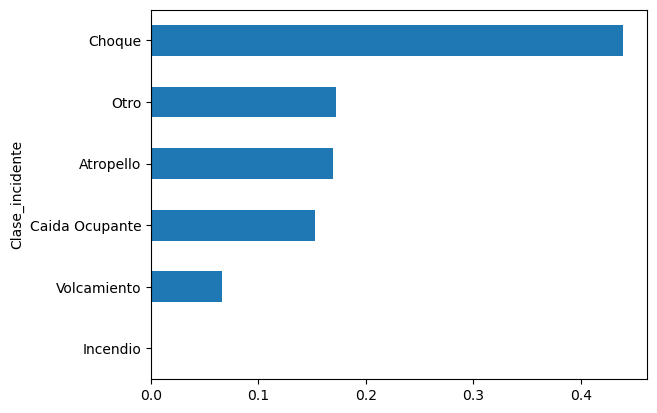

In [125]:
#Variable Nominal
df1['Clase_incidente'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: ylabel='Sexo'>

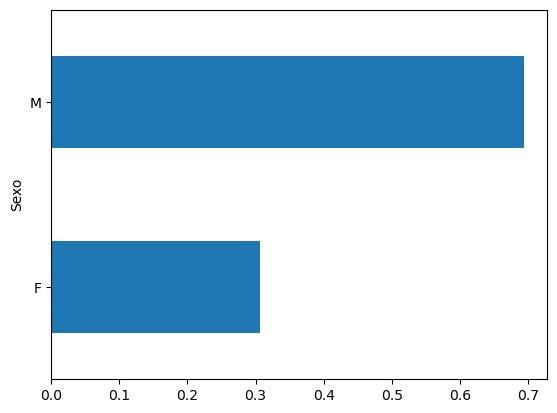

In [126]:
#Variable Nominal
df1['Sexo'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: ylabel='Condicion'>

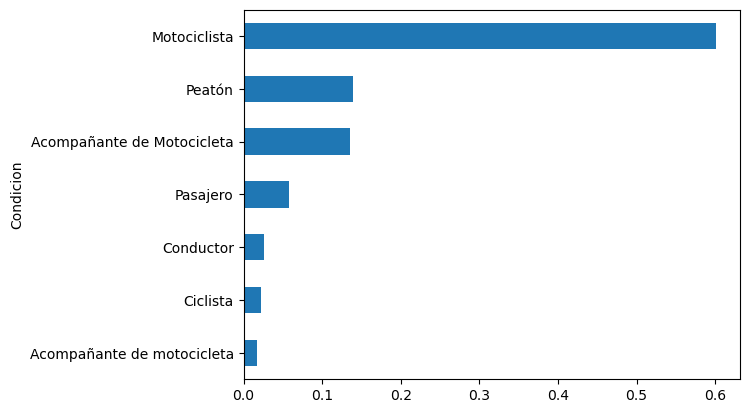

In [127]:
#Variable Nominal
df1['Condicion'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: ylabel='Comuna'>

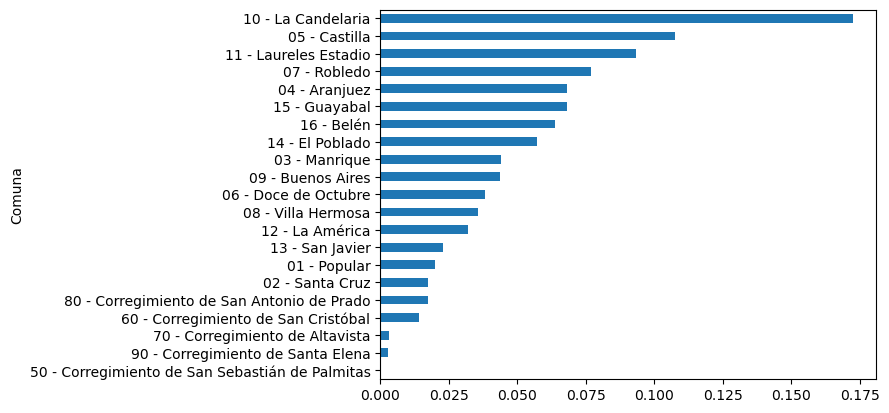

In [128]:
#Variable Nominal
df1['Comuna'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: xlabel='Gravedad_victima'>

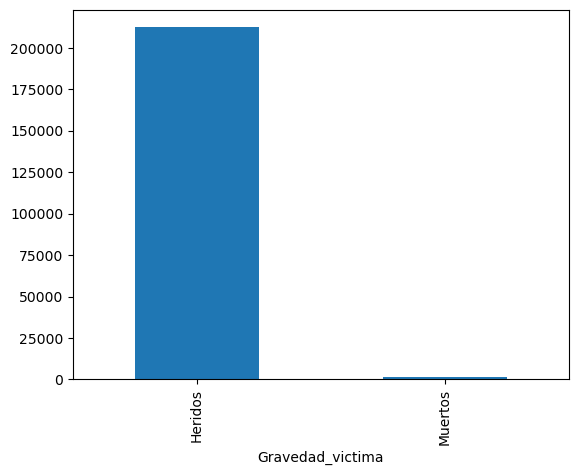

In [129]:
#Variables Ordinales
df1['Gravedad_victima'].value_counts().plot(kind='bar')

<Axes: xlabel='Grupo_edad'>

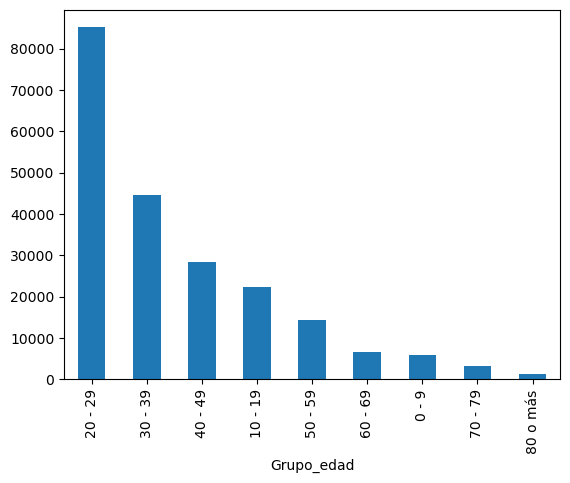

In [130]:
#Variables Ordinales
df1['Grupo_edad'].value_counts().plot(kind='bar')

<Axes: xlabel='Dia_semana'>

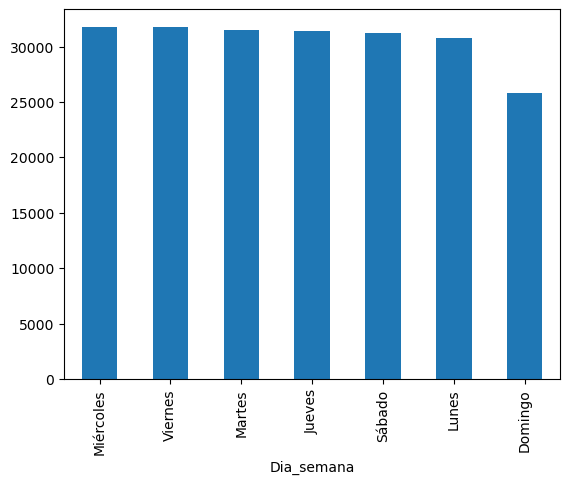

In [131]:
#Variables Ordinales
df1['Dia_semana'].value_counts().plot(kind='bar')

<Axes: xlabel='Mes'>

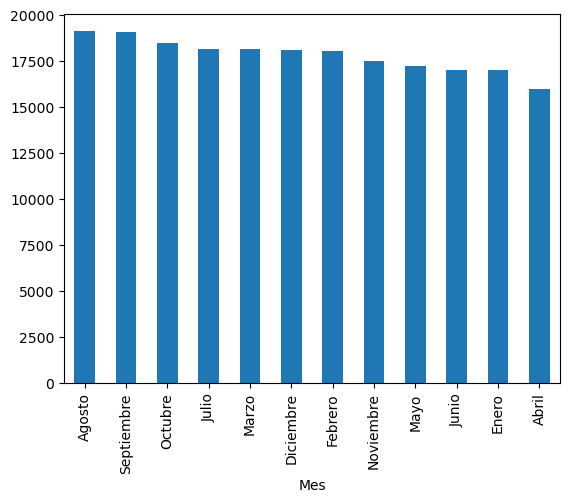

In [132]:
#Variables Ordinales
df1['Mes'].value_counts().plot(kind='bar')

<Axes: xlabel='Año'>

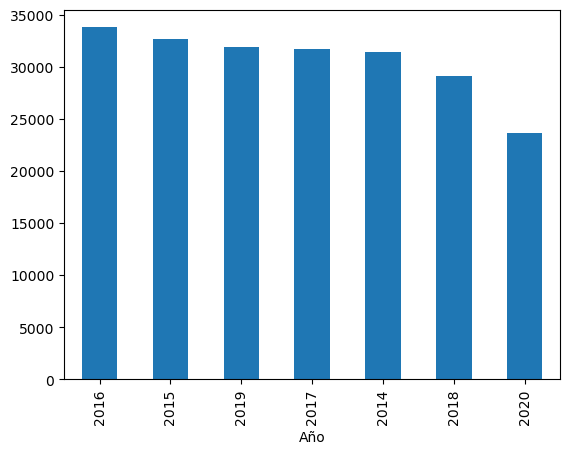

In [133]:
#Variables Ordinales
df1['Año'].value_counts().plot(kind='bar')

Para las variables ordinales, haga un gráfico de barras vertical de la tabla de frecuencia acumulada, ordenada de acuerdo al orden de las categorías.

Para las variables ordinales, calcule la mediana, y los quartiles 1, 2 y 3.

<Axes: xlabel='Gravedad_victima'>

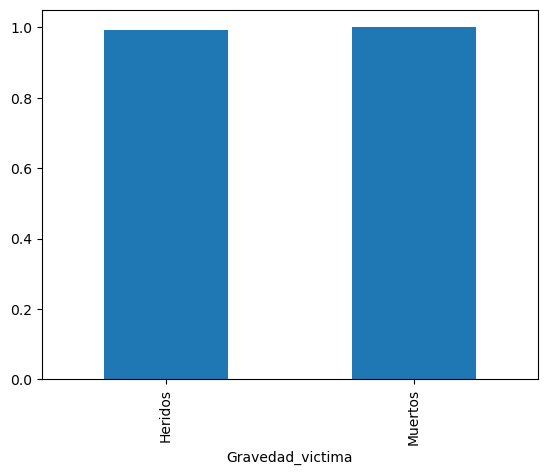

In [134]:
# Variable Gravedad_victima
df1['Gravedad_victima'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

<Axes: xlabel='Grupo_edad'>

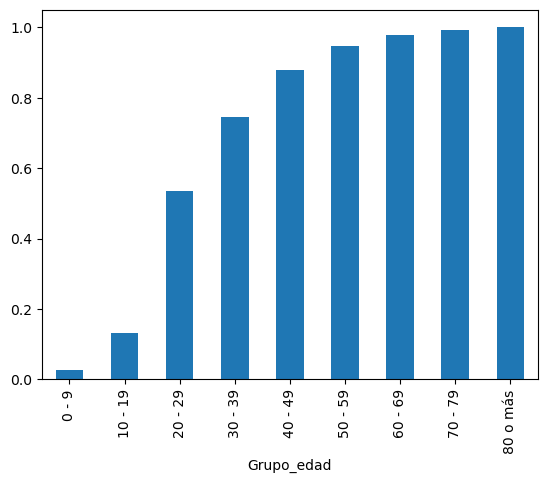

In [135]:
# Variable Grupo_edad
df1['Grupo_edad'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

<Axes: xlabel='Dia_semana'>

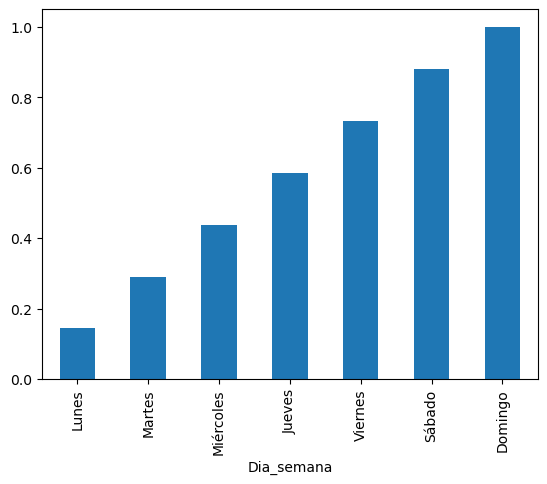

In [136]:
# Variable Dia_semana
df1['Dia_semana'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

<Axes: xlabel='Mes'>

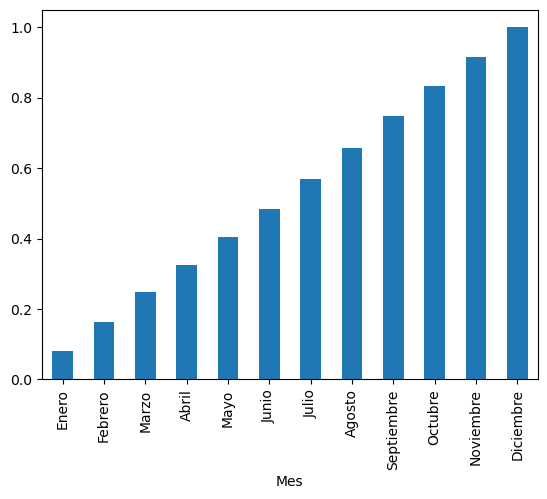

In [137]:
# Variable Mes
df1['Mes'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

<Axes: xlabel='Año'>

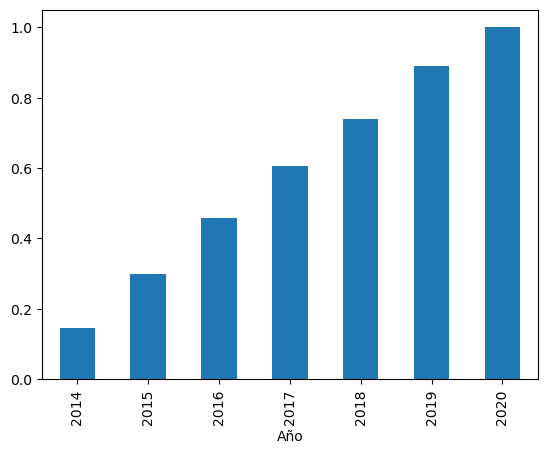

In [138]:
# Variable Año
df1['Año'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

In [143]:
#Variable Gravedad_victima
#Mediana
df1['Gravedad_victima'].cat.categories[df1['Gravedad_victima'].cat.codes.median().astype(int)]

Cuartiles


Index(['Heridos', 'Heridos', 'Heridos'], dtype='object')

In [144]:
#Variable Gravedad_victima
#cuartiles
df1['Gravedad_victima'].cat.categories[df1['Gravedad_victima'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index(['Heridos', 'Heridos', 'Heridos'], dtype='object')

In [147]:
#Variable Grupo_edad
#Mediana
df1['Grupo_edad'].cat.categories[df1['Grupo_edad'].cat.codes.median().astype(int)]

'20 - 29'

In [146]:
#Variable Grupo_edad
#cuartiles
df1['Grupo_edad'].cat.categories[df1['Grupo_edad'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index(['20 - 29', '20 - 29', '40 - 49'], dtype='object')

In [148]:
#Variable Dia_semana
#Mediana
df1['Dia_semana'].cat.categories[df1['Dia_semana'].cat.codes.median().astype(int)]

'Jueves'

In [149]:
#Variable Dia_semana
#cuartiles
df1['Dia_semana'].cat.categories[df1['Dia_semana'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index(['Martes', 'Jueves', 'Sábado'], dtype='object')

In [150]:
#Variable Mes
#Mediana
df1['Mes'].cat.categories[df1['Mes'].cat.codes.median().astype(int)]

'Julio'

In [151]:
#Variable Mes
#cuartiles
df1['Mes'].cat.categories[df1['Mes'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index(['Abril', 'Julio', 'Octubre'], dtype='object')

In [152]:
#Variable Año
#Mediana
df1['Año'].cat.categories[df1['Año'].cat.codes.median().astype(int)]

np.int64(2017)

In [153]:
#Variable Año
#cuartiles
df1['Año'].cat.categories[df1['Año'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index([2015, 2017, 2019], dtype='int64')